# Eigenstates: Solving the Infinite Square Well
Let the well have actual width L, then $$0 < x < L$$
Boundary conditions: $$\psi(0) = \psi(L) = 0$$
Analytical energies: $$E_n = \frac{n^2 \pi^2 \hbar^2}{2 m L^2}$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh_tridiagonal

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

hbar = 1.0
m = 1.0  # Mass of the particle
L = 1.0  # Length of the box
N = 500

In [6]:
from src.hamiltonian import kinetic_operator, build_hamiltonian

ModuleNotFoundError: No module named 'src'

For $0 < x < L$, the known boundary values are $$\psi (0) = \psi (L) = 0,$$ therefore we only solve for the $N$ interior points as these are unknowns.
$N$ counts the interior points, therefore $$\Delta x = \frac{L}{N + 1}$$.

In [ ]:
x = np.linspace(0, L, N+2)
x_interior = x[1:-1]  # Exclude boundary points
dx = x[1] - x[0]

### Constructing the second derivative matrix
In order to numerically solve the Schrödinger equation, the second derivative operator, which is continuous, must be converted to a finite difference approximation using the central difference method.

### Central difference method
The formula for central difference is 
$$\psi''(x_i) \approx \frac{\psi_{i+1} - 2 \psi_i + \psi_{i-1}}{(\Delta x)^2}.$$
This means that, at each point on the grid, the value of the second derivative depends on the wavefunction at that point as well as its two nearest neighbours. Therefore, the finite difference expression coefficients are
$$1,\quad -2,\quad 1.$$
Applying this relation at each grid point, we can write the operator for the second derivative as the tridiagonal matrix
$$
D_2 =
\frac{1}{(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & \cdots \\
1 & -2 & 1 & 0 & \cdots \\
0 & 1 & -2 & 1 & \cdots \\
0 & 0 & 1 & -2 & \ddots \\
\vdots & \vdots & \vdots & \ddots & \ddots
\end{pmatrix},
$$
with the coefficient $(-2)$ forming the main diagonal, $(+1)$ forming the diagonal immediately above and below the main diagonal, and the entire matrix being divided by $((\Delta x)^2)$.
The matrix is therefore a discrete approximation of the continuous spatial second derivative operator 
$$\frac{\partial^2}{\partial x^2}$$
in the Schrödinger equation, which we can later use to discretise the Hamiltonian as a matrix.

### Derivative matrix:

In [ ]:
main_diag = -2 * np.ones(N)
off_diag = np.ones(N - 1)

# −2 forms main diagonal; +1 forms upper/lower diagonals; division by dx^2 completes D_2​

D2 = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1]) / dx**2  # Second derivative operator

This is an infinite well, therefore 
$$V = 0$$
for 
$$0 < x < L$$
inside the well, and 
$$V = \infty$$
for 
$$x < 0 $$
and 
$$L < x$$
outside the well, and we get 
$$\hat{H} = - \frac{\hbar ^2}{2m} \times D_2.$$
The grid points represented all fall inside the well with 
$$V = 0,$$
and the infinite walls are enforced by the boundary conditions.

In [ ]:
H = - (hbar**2 / (2 * m)) * D2

### Solving the Eigenvalue Problem
We should get $H \psi_n = E_n \psi_n$

In [ ]:
energies, states = eigsh(H, k=5, which='SM')  # Compute the 5 lowest eigenvalues and eigenvectors
order = np.argsort(energies)
energies = energies[order]  # Sort energies in ascending order
states = states[:, order]  # Sort eigenvectors according to sorted energies

print('Energies: ', energies)

Energies:  [  4.93478603  19.73895008  44.41191004  78.95269575 123.35994903]


Now we will calculate the exact answer:

In [ ]:
n = np.arange(1, 6)  # Quantum numbers for the first 5 states
E_exact = (n**2 * np.pi**2 * hbar**2) / (2 * m * L**2)  # Exact energies for a particle in a box
print('Exact Energies: ', E_exact)

Exact Energies:  [  4.9348022   19.7392088   44.4132198   78.95683521 123.37005501]


Comparison:

In [ ]:
for i in range(5):
    error = abs(energies[i] - E_exact[i]) / E_exact[i] * 100
    print(
        f"n = {i + 1}: Numerical = {energies[i]:.6f}, " 
        f"exact = {E_exact[i]:.6f}, "
        f"error = {error:.6f}%"
    )

n = 1: Numerical = 4.934786, exact = 4.934802, error = 0.000328%
n = 2: Numerical = 19.738950, exact = 19.739209, error = 0.001311%
n = 3: Numerical = 44.411910, exact = 44.413220, error = 0.002949%
n = 4: Numerical = 78.952696, exact = 78.956835, error = 0.005243%
n = 5: Numerical = 123.359949, exact = 123.370055, error = 0.008192%


### Convergence Test

Testing how the numerical error changes with refinement of the spatial grid is much stronger than just one single comparison between the numerical and analytical eigenvalues.
The second derivative can be approximated with second-order accuracy using the central difference formula:

$$
\frac{d^2\psi}{dx^2}
\approx
\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{(\Delta x)^2}.
$$

As it is second-order accurate, the central difference approximation possesses a discretisation error that is expected to scale as

$$
\epsilon \propto (\Delta x)^2.
$$

For the infinite square well, we use various grid resolutions to calculate the energy in the ground state and compare it to the exact result,

$$
E_1^{\mathrm{exact}}
=
\frac{\pi^2\hbar^2}{2mL^2}.
$$

We can define the relative error as

$$
\epsilon
=
\frac{|E_1^{\mathrm{numerical}}-E_1^{\mathrm{exact}}|}
{|E_1^{\mathrm{exact}}|}.
$$

N = number of interior grid points, $$\psi (0) = 0, \psi (L) = 0$$ spacing is $$\Delta x = \frac{L}{N + 1}$$

Since we already know the boundary values are zero, we do not need to include them in the Hamiltonian.

In [ ]:
# Dimensionless units
hbar = 1.0
m = 1.0
L = 1.0  # Length of the box

In [ ]:
E1_exact = (np.pi**2 * hbar**2) / (2 * m * L**2)
print(f"Exact ground state energy in dimensionless units: {E1_exact}")

Exact ground state energy in dimensionless units: 4.934802200544679


$$\hbar = m = L = 1$$ Therefore $$E_1 = \frac{\pi ^2}{2} \approx 4.9348$$


### Function to Calculate $E_1$

The numerical ground-state energy of a 1D infinite square well is calculated using a second-order central-difference Hamiltonian. This is carried out by the function numerical_ground_state_energy defined below.

Parameters:
N : int
    Number of interior spatial grid points.
L : float
    Width of the well.
hbar : float
     Reduced Planck constant.
m : float
    Particle mass.

Returns
E1 : float
    Numerical ground-state energy.
dx : float
    Spatial grid spacing.


In [ ]:
def numerical_ground_state_energy(N, L=1.0, hbar=1.0, m=1.0):
    # Grid spacing for N interior points
    dx = L / (N + 1)

    # Main diagonal of the Hamiltonian
    main_diagonal = np.full(
        N,
        hbar**2 / (m * dx**2)
    )

    # Off-diagonal elements
    off_diagonal = np.full(
        N - 1,
        -hbar**2 / (2 * m * dx**2)
    )

    # Calculating the eigenvalues
    eigenvalues = eigh_tridiagonal(
        main_diagonal,
        off_diagonal,
        eigvals_only=True
    )

    # The lowest eigenvalue is the ground-state energy
    E1 = eigenvalues[0]

    return E1, dx

Testing the function:

In [ ]:
E1_test, dx_test = numerical_ground_state_energy(N=100)
print("Grid spacing =", dx_test)
print("Numerical ground-state energy =", E1_test)
print("Exact ground-state energy =", E1_exact)

Grid spacing = 0.009900990099009901
Numerical ground-state energy = 4.934404339433664
Exact ground-state energy = 4.934802200544679


In [ ]:
N_vals = ([50, 100, 200, 400, 800])  # Increasingly fine spatial grids to test convergence

As N increases, $\Delta x$ decreases, therefore we can expect the approximation to increase in accuracy.

In [ ]:
# Empty lists for results
dx_vals = []
E1_numerical_vals = []
err_vals = []

### Convergence calculation:

In [ ]:
for N in N_vals:

    # First calculate the numerical ground-state energy
    E1_numerical, dx = numerical_ground_state_energy(
        N,
        L=L,
        hbar=hbar,
        m=m
    )

    # Now calculate the relative error
    rel_err = abs(E1_numerical - E1_exact) / abs(E1_exact)

    # Finally store the results
    dx_vals.append(dx)
    E1_numerical_vals.append(E1_numerical)
    err_vals.append(rel_err)

    # Calculations should now be performed, results should be stored in the lists
    

In [ ]:
# Converting lists to numpy arrays for easier mathematical analysis and plotting
dx_vals = np.array(dx_vals)
E1_numerical_vals = np.array(E1_numerical_vals)
err_vals = np.array(err_vals)

In [ ]:
# Printing the results
print("N     dx             E1 numerical      Relative error")
print("-" * 53)

for N, dx, E1_num, err in zip(
    N_vals,
    dx_vals,
    E1_numerical_vals,
    err_vals
):
    print(f"{N:<6d}{dx:<15.8e}{E1_num:<18.10f}{err:.8e}")

N     dx             E1 numerical      Relative error
-----------------------------------------------------
50    1.96078431e-02 4.9332419549      3.16171861e-04
100   9.90099010e-03 4.9344043394      8.06235174e-05
200   4.97512438e-03 4.9347017407      2.03574271e-05
400   2.49376559e-03 4.9347769601      5.11478261e-06
800   1.24843945e-03 4.9347958745      1.28192633e-06


Notice that every time $\Delta x$ approximately halves, the error should decrease by a factor of about four. This is because $$\epsilon \propto (\Delta x)^2,$$ therefore if $$\Delta x \rightarrow \frac{\Delta x}{2},$$ then $$\epsilon \rightarrow (\frac{1}{2})^2 \epsilon = \frac{1}{4} \epsilon.$$
This demonstrates second-order convergence.

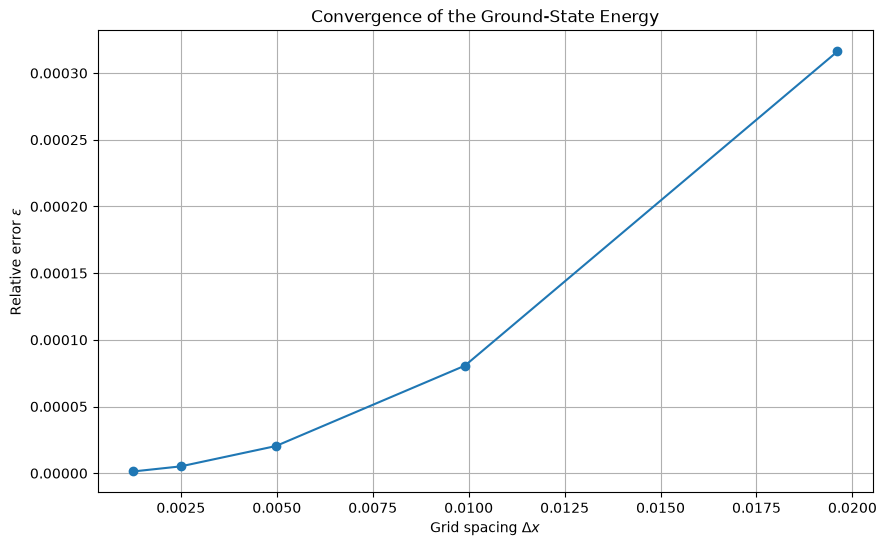

In [ ]:
# Plotting the error vs grid spacing to show the convergence of the numerical method: Regular plot
plt.figure(figsize=(10, 6))

plt.plot(dx_vals, err_vals, "o-")

plt.xlabel(r"Grid spacing $\Delta x$")
plt.ylabel(r"Relative error $\epsilon$")
plt.title("Convergence of the Ground-State Energy")

plt.grid(True)

plt.show()

The above plot resembles a quadratic relationship, so a log-log graph will better show the relationship and produce a more linear plot. This is because the relationship $$\epsilon = C(\Delta x)^p$$ for a power law gives $$\log(\epsilon ) = p \log(\Delta x) + \log(C)$$ by taking logarithms. The gradient should be equal to p, where $$p \approx 2$$ since central differences are second order.

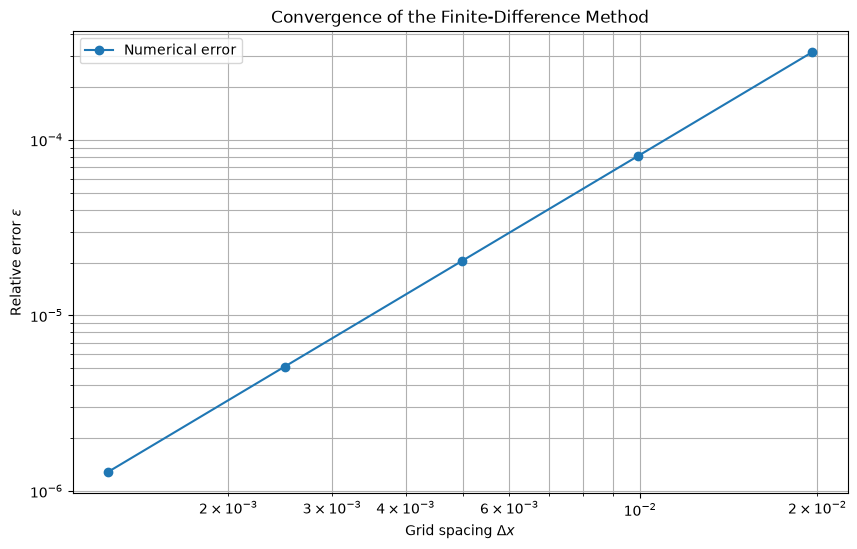

In [ ]:
# Plotting the error vs grid spacing to show the convergence of the numerical method: Log-log plot
plt.figure(figsize=(10, 6))

plt.loglog(
    dx_vals,
    err_vals,
    "o-",
    label="Numerical error"
)

plt.xlabel(r"Grid spacing $\Delta x$")
plt.ylabel(r"Relative error $\epsilon$")
plt.title("Convergence of the Finite-Difference Method")

plt.grid(True, which="both")
plt.legend()

plt.show()

### Measuring the actual convergence order
The above graph is approximately a straight line, so we will now use np.polyfit to fit an actual straight line and measure $p$. We already have $$\log(\epsilon ) = p \log(\Delta x) + \log(C),$$ therefore $p$ will simply be the slope of the line fitted to a plot of error vs grid spacing.

In [ ]:
log_dx = np.log(dx_vals)
log_err = np.log(err_vals)
slope, intercept = np.polyfit(log_dx, log_err, 1)

print(f"Measured order of convergence=", slope)
print(f"Measured order of convergence (4dp)=", f"{slope:.4f}")

Measured order of convergence= 1.999953078564656
Measured order of convergence (4dp)= 2.0000


The order of convergence has been mathematically measured as 2.0000 to four decimal places as expected. Therefore, we have demonstrated numerically that $$\epsilon \propto (\Delta x)^2$$. This is further seen in the plot below, in which a reference line having $$p = 2$$ has been added to visually demostrate the second order convergence.

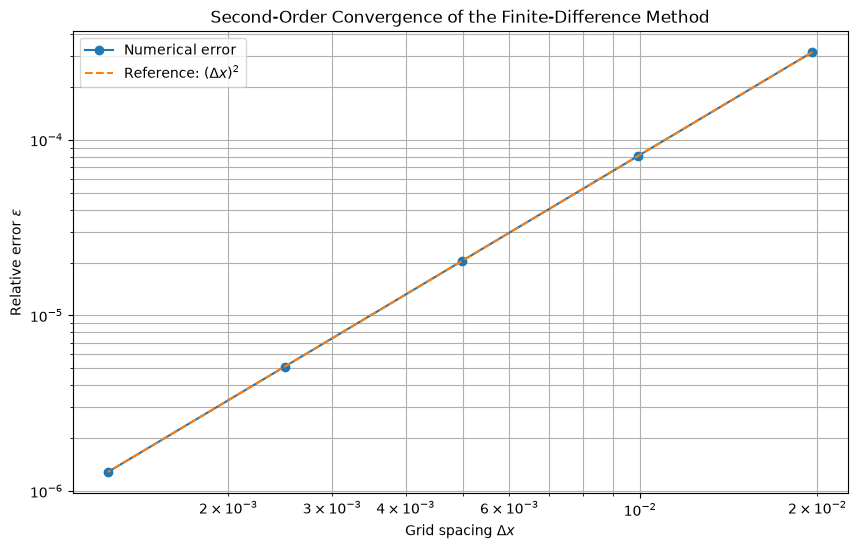

In [ ]:
reference_err = (
    err_vals[0]
    * (dx_vals / dx_vals[0])**2
)

plt.figure(figsize=(10, 6))

plt.loglog(
    dx_vals,
    err_vals,
    "o-",
    label="Numerical error"
)

plt.loglog(
    dx_vals,
    reference_err,
    "--",
    label=r"Reference: $(\Delta x)^2$"
)

plt.xlabel(r"Grid spacing $\Delta x$")
plt.ylabel(r"Relative error $\epsilon$")
plt.title("Second-Order Convergence of the Finite-Difference Method")

plt.grid(True, which="both")
plt.legend()

plt.show()

### Final convergence plot to store in the figures

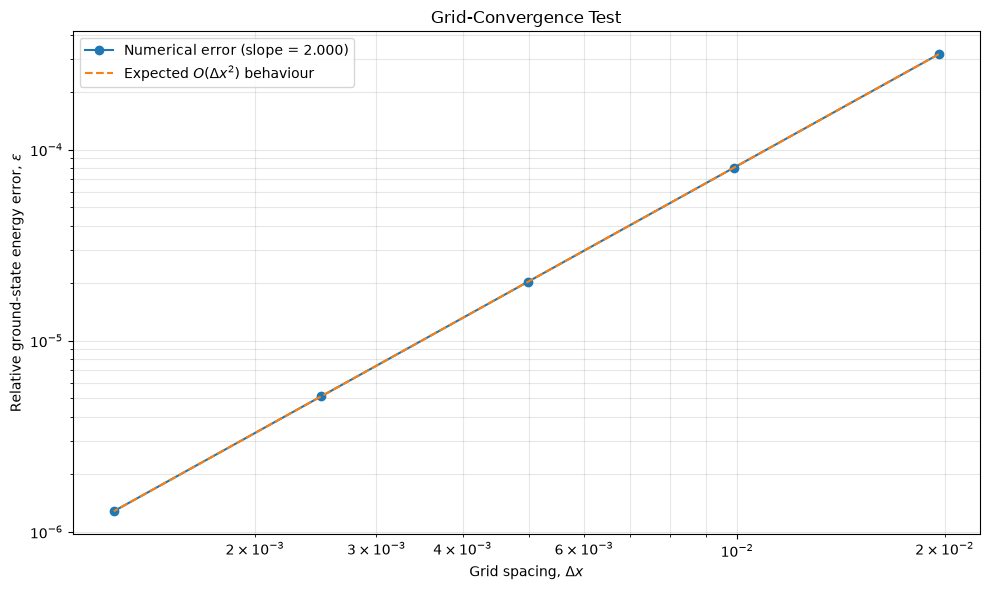

In [ ]:
plt.figure(figsize=(10, 6))

plt.loglog(
    dx_vals,
    err_vals,
    "o-",
    label=f"Numerical error (slope = {slope:.3f})"
)

plt.loglog(
    dx_vals,
    reference_err,
    "--",
    label=r"Expected $O(\Delta x^2)$ behaviour"
)

plt.xlabel(r"Grid spacing, $\Delta x$")
plt.ylabel(r"Relative ground-state energy error, $\epsilon$")
plt.title("Grid-Convergence Test")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../figures/inf_well_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation of the convergence test results
We have shown that refining the spatial grid systematically decreases the relative error present in the ground state energy calculation.
Plotting the relative error against grid spacing produced a roughly quadratic shape, and so a log-log plot was implemented. This showed an approximately straight line, meaning the relationship between the relative error and the grid spacing must be close to $$\epsilon \propto (\Delta x)^2,$$ meaning the order of convergence should be roughly $$p \approx 2.$$ To test this further, np.polyfit was used to fit an actual straight line to the graph, and its slope was measured to give an estimate for $p$, which turned out to be $2.0000$ to four decimal places, showing that the convergence was indeed second order. The agreement therefore provides a stronger validation of the implementation than comparing a single numerical eigenvalue with the analytical solution. We can therefore conclude that the finite-difference Hamiltonian converges at the theoretically expected rate.

## Numerical eigenstates
The energy eigenvalues and their corresponding numerical eigenvectors are returned by the solver. Each eigenstate of the discretised Hamiltonian is represented by a 'states' column, for example the numerical ground state is represented by
$$\texttt{states[:,0]}.$$
In order to convert the eigenvectors to wavefunctions, they must first be normalised. This is because the probability of finding the particle somewhere inside the well must equal one for the wavefunction to work mathematically. The continuous normalisation condition is given by
$$\int |\psi_n(x)|^2\,dx = 1.$$

In [ ]:
psi_1 = states[:, 0]  # Ground state wavefunction

The matrix eigensolver returns eigenvectors which have been normalised as discrete vectors, but for an actual physical wavefunction we require
$$\int |\psi_n(x)|^2\,dx = 1.$$
Therefore we must integrate numerically over the spatial grid in order to renormalise each of the numerical eigenstates.

### Normalising the ground state

In [ ]:
psi_1 = psi_1 / np.sqrt(
    np.trapezoid(np.abs(psi_1)**2, x_interior)
)

We must first calculate
$$|\psi_1|^2,$$
and then approximate
$$\int|\psi_1(x)|^2dx$$
using np.trapezoid(..., x_interior).
The square root then gives the norm
$$\sqrt{\int|\psi_1|^2dx}$$
which we can divide by to ensure the integral is equal to one.

### Numerical normalisation check

In [ ]:
normalisation = np.trapezoid(
    np.abs(psi_1)**2,
    x_interior
)
print(f"Normalisation of the wavefunction at ground state: {normalisation}")

Normalisation of the wavefunction at ground state: 1.0


### Ground state eigenfunction plot

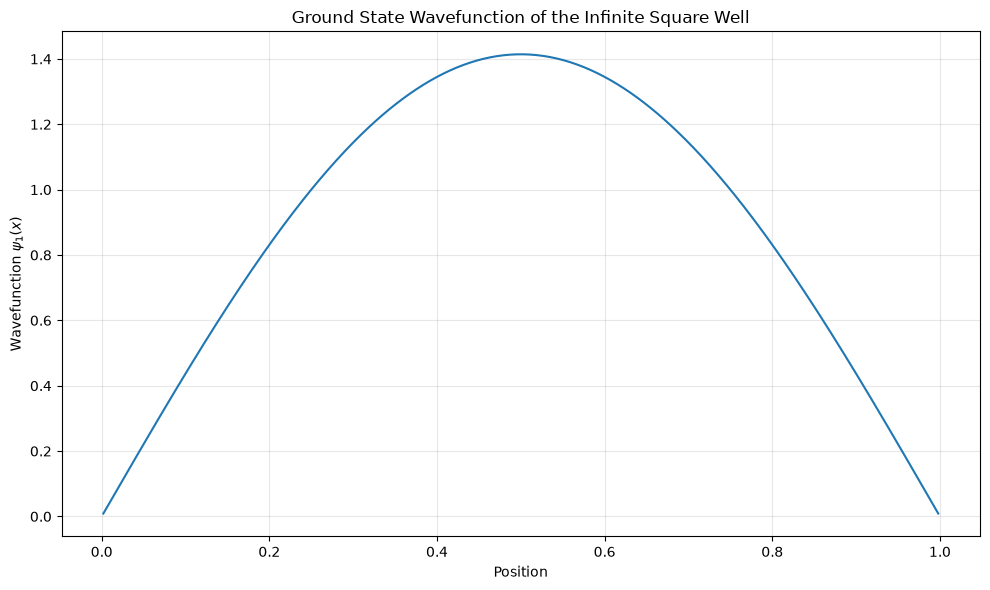

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x_interior, psi_1)
plt.xlabel("Position")
plt.ylabel(fr"Wavefunction $\psi_1(x)$")
plt.title("Ground State Wavefunction of the Infinite Square Well")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In the above plot we see that the ground state wavefunction has the expected smooth single lobe shape without any internal nodes.

### Normalising the first four states
Here we use a 'for' loop to efficiently normalise the first four states rather than manually repeating the calculation.

In [ ]:
normalised_states = []

for n in range(4):
    psi_n = states[:, n]  # nth eigenstate
    norm = np.sqrt(
        np.trapezoid(np.abs(psi_n)**2, x_interior)
    )

    psi_n = psi_n / norm  # Normalise the wavefunction
    normalised_states.append(psi_n)

The nth state is given by normalised_states[n-1] (taking the ground state as the first state).

### Plotting the first four states
We will plot the first four states on one graph to enable easy comparison of node patterns.

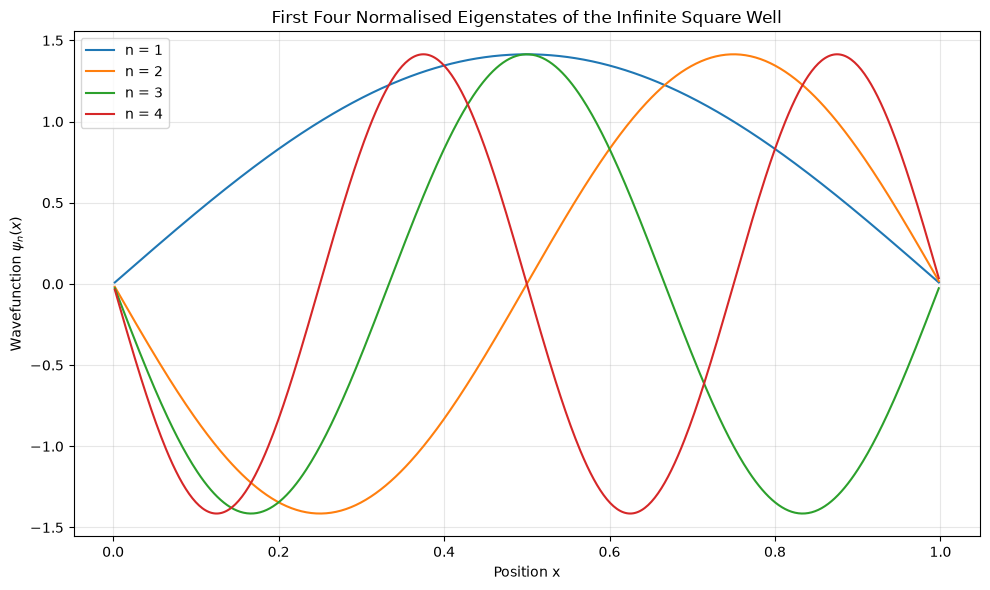

In [ ]:
plt.figure(figsize=(10, 6))

for n in range(4):

    psi_n = normalised_states[n]

    plt.plot(
        x_interior,
        psi_n,
        label=f"n = {n + 1}"
    )

plt.xlabel("Position x")
plt.ylabel(fr"Wavefunction $\psi_n(x)$")
plt.title("First Four Normalised Eigenstates of the Infinite Square Well")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The plot shows that oscillation increases as n increases. We can see that the ground state $(n = 1)$ has zero internal nodes, the next state $(n = 2)$ has one, and so on, so that we have 
$$\text{number of internal nodes} = n - 1$$
for the $n^{th}$ infinite well eigenstate.
Therefore the numerical eigenstates show the expected increase in oscillatory structure as the quantum number rises.
The eigenstate computation is qualitatively validated as the numerical eigenvectors reproduce the expected pattern.

We will now plot individual figures below for more precise node views as the curves on the shared graph may overlap and make the nodes less visible.

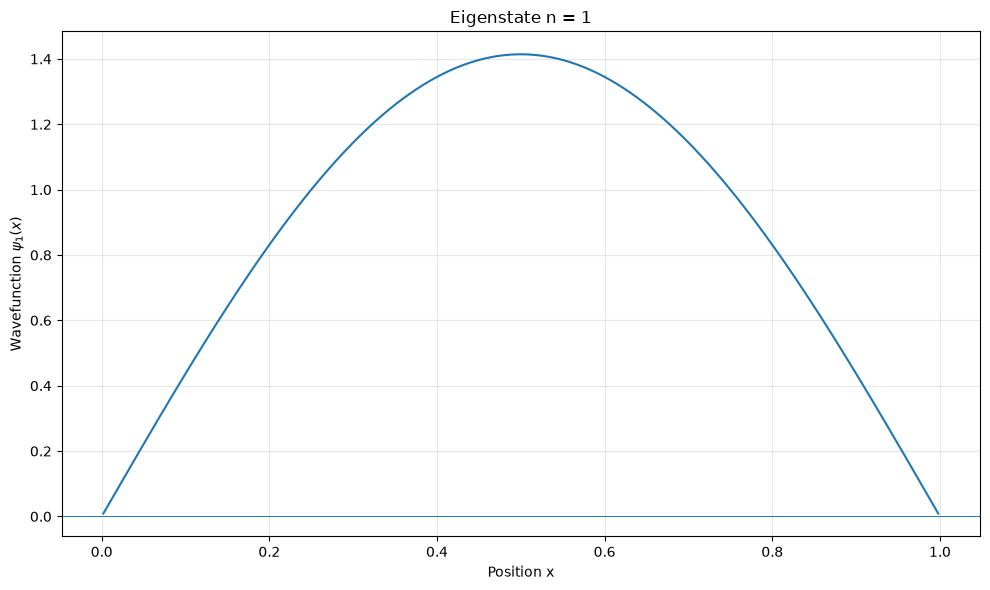

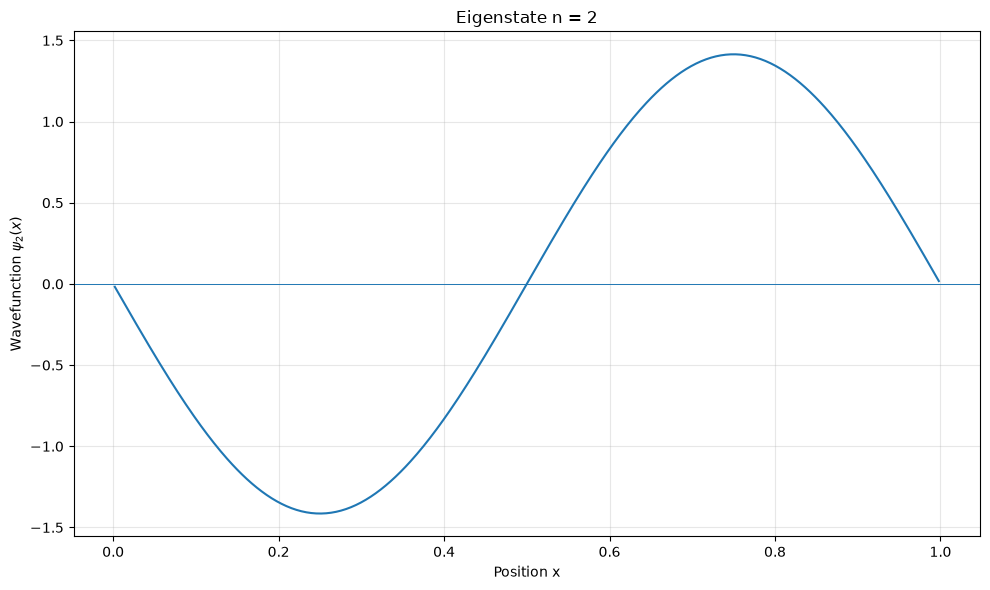

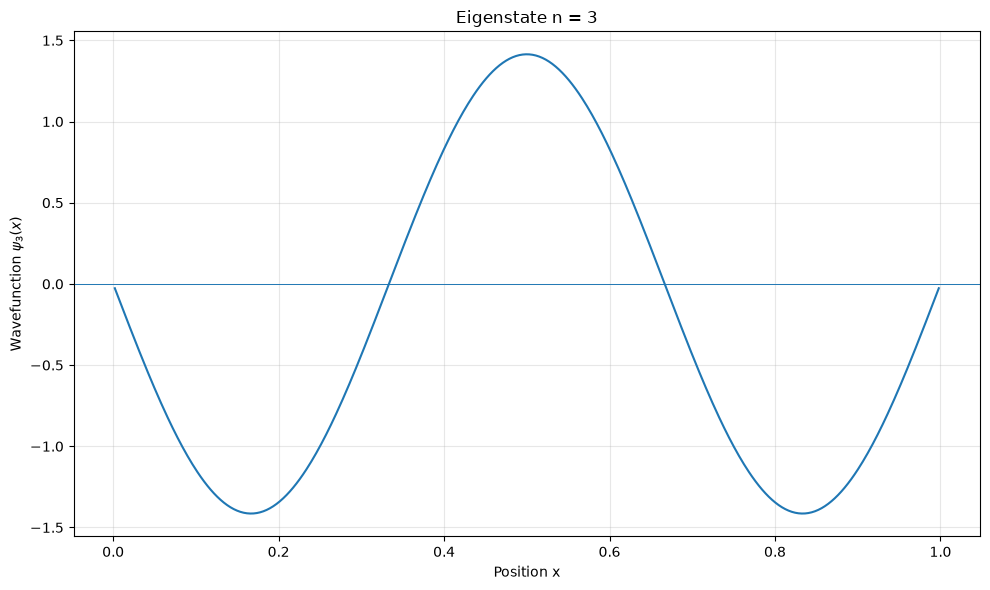

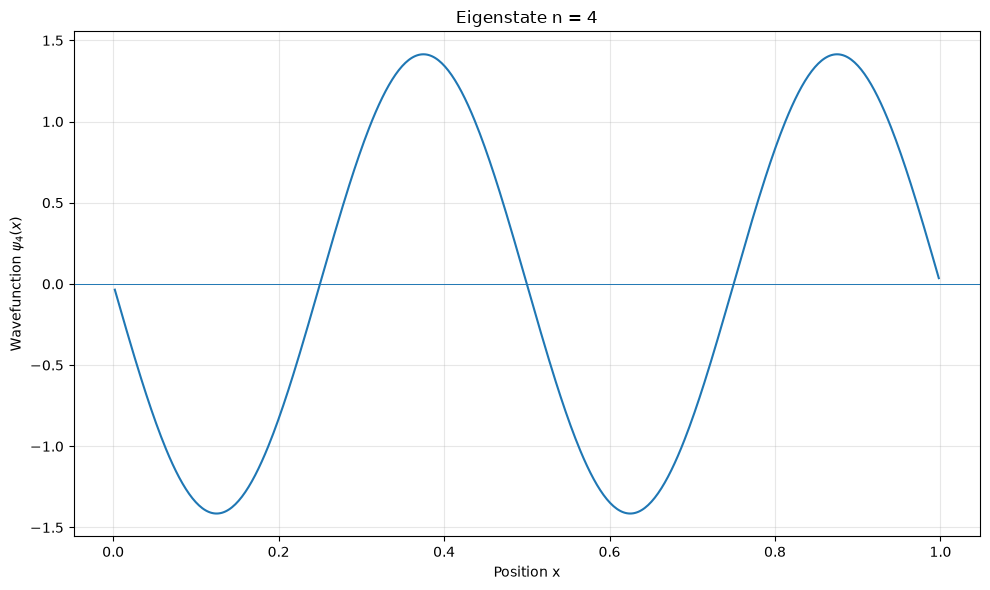

In [ ]:
for n in range(4):

    psi_n = normalised_states[n]

    plt.figure(figsize=(10, 6))
    plt.plot(x_interior, psi_n)
    plt.axhline(0, linewidth=0.7)

    plt.xlabel("Position x")
    plt.ylabel(fr"Wavefunction $\psi_{{{n+1}}}(x)$")
    plt.title(f"Eigenstate n = {n + 1}")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Comparison with analytical eigenfunctions

The exact eigenfunctions of the infinite square well are given by

$$
\psi_n(x)
=
\sqrt{\frac{2}{L}}
\sin\left(\frac{n\pi x}{L}\right).
$$

The numerical eigenfunctions can therefore be directly compared with the analytical solutions.

We will now calculate the analytical ground state.

In [ ]:
psi_1_exact = np.sqrt(2 / L) * np.sin(np.pi * x_interior / L)

if np.dot(psi_1, psi_1_exact) < 0:
    psi_1 = -psi_1

An eigenvector returned by the numerical eigensolver has an arbitrary overall sign, meaning a numerical eigenfunction is able to appear as $\psi_n(x)$ or $-\psi_n(x)$.
$$|-\psi_n(x)|^2 = |\psi_n(x)|^2,$$
therefore these represent the same physical state. Here, the sign of the numerical eigenfuction has been made to match that of the analytical eigenfuction to enable easier visual comparison.

Now we can compare the numerical and analytical ground states by plotting them together.

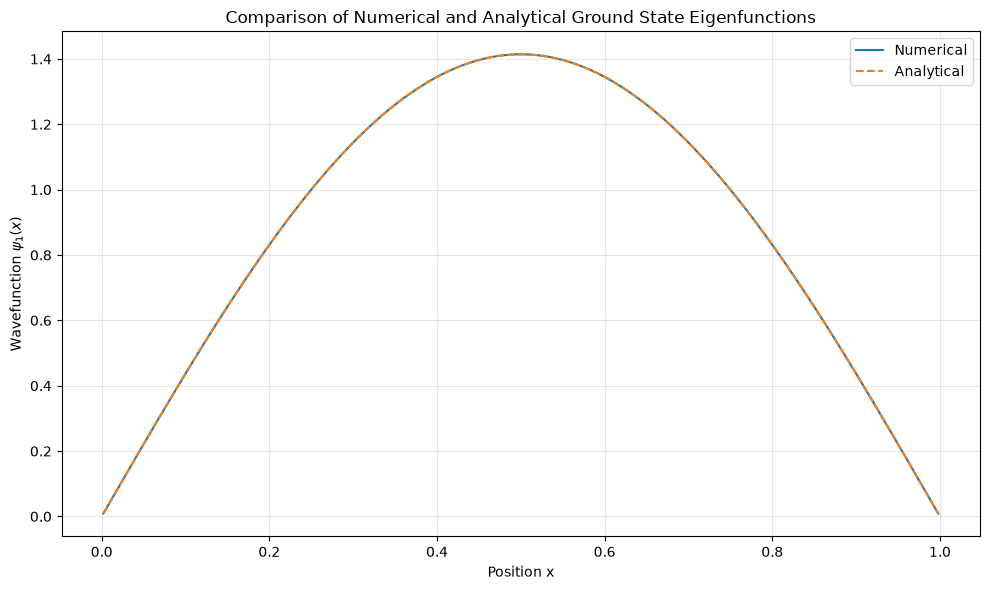

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(x_interior, psi_1, label="Numerical")

plt.plot(x_interior, psi_1_exact, label="Analytical", linestyle="--")

plt.xlabel("Position x")
plt.ylabel(fr"Wavefunction $\psi_1(x)$")
plt.title("Comparison of Numerical and Analytical Ground State Eigenfunctions")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The two curves appear to be in very close agreement with each other, further validating the finite difference solution.

We will now plot all four eigenstates.

### Probability densities

The spatial probability density associated with an eigenstate is

$$
P_n(x)=|\psi_n(x)|^2.
$$

I will therefore also plot the probability densities of the numerical eigenstates, as these are physical observables, which are very useful.

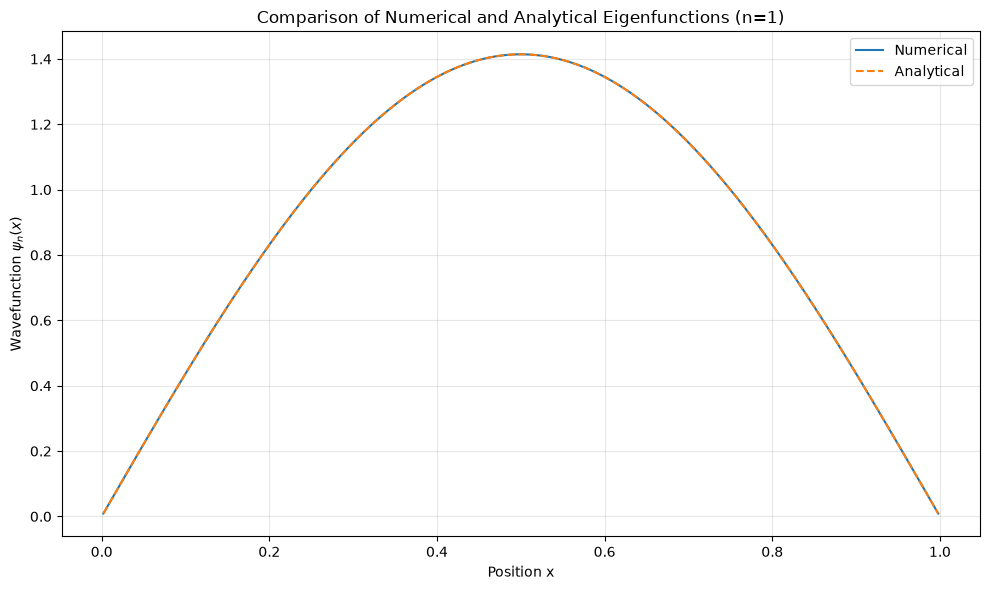

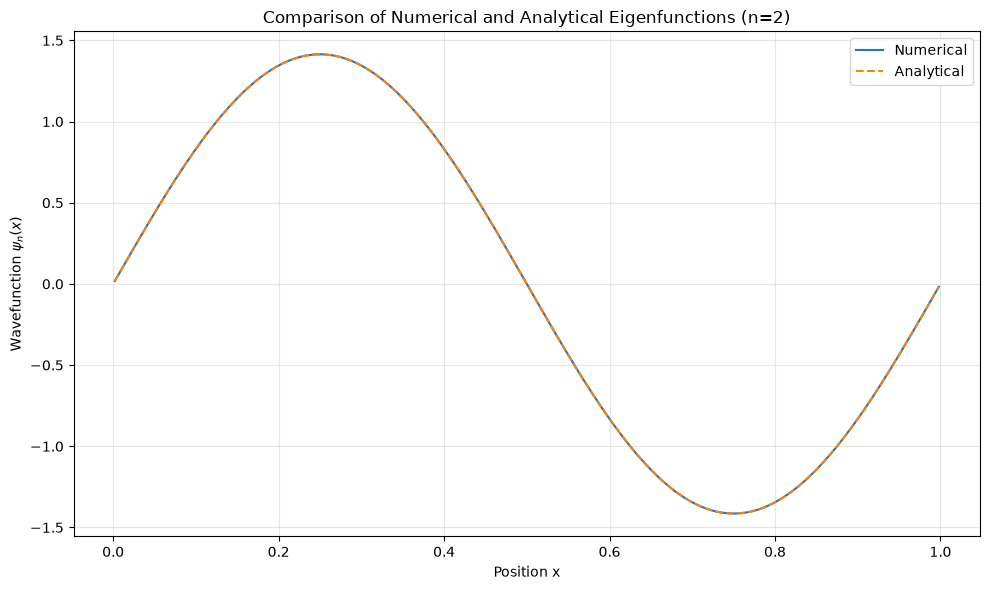

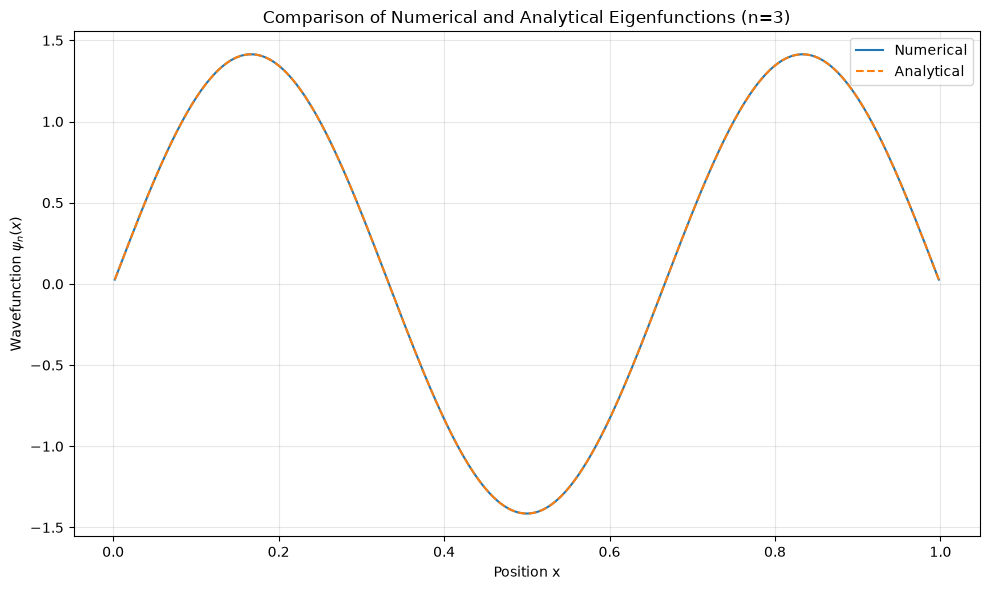

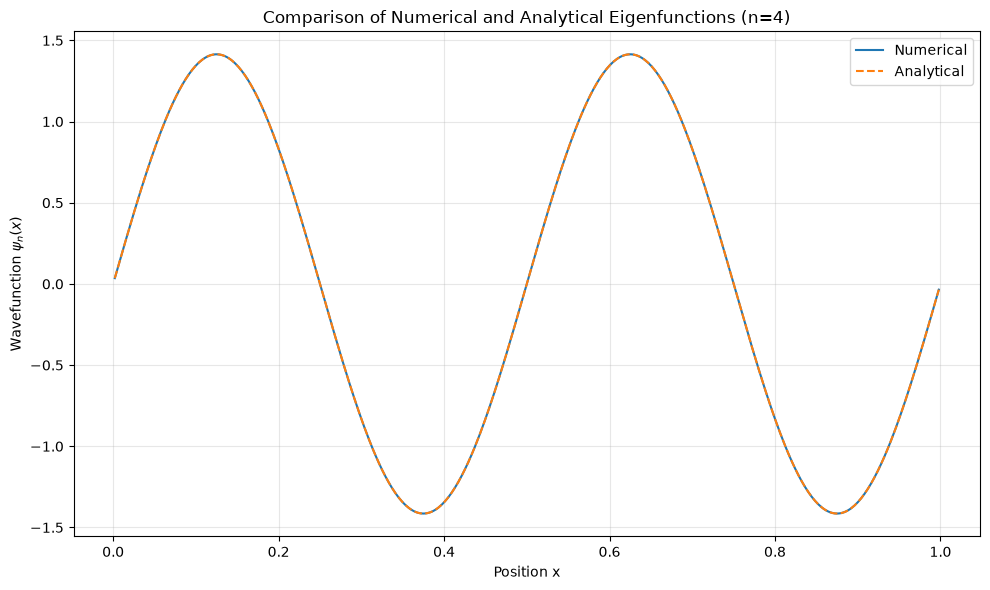

In [ ]:
for n in range(1, 5):
    psi_num = normalised_states[n - 1]  # Numerical eigenstate
    psi_exact = np.sqrt(2 / L) * np.sin(n * np.pi * x_interior / L)  # Analytical eigenstate

    # Aligning arbitrary numerical sign
    if np.dot(psi_num, psi_exact) < 0:
        psi_num = -psi_num

    plt.figure(figsize=(10, 6))
    plt.plot(x_interior, psi_num, label="Numerical")
    plt.plot(x_interior, psi_exact, label="Analytical", linestyle="--")
    plt.xlabel("Position x")
    plt.ylabel(fr"Wavefunction $\psi_n(x)$")
    plt.title(f"Comparison of Numerical and Analytical Eigenfunctions (n={n})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

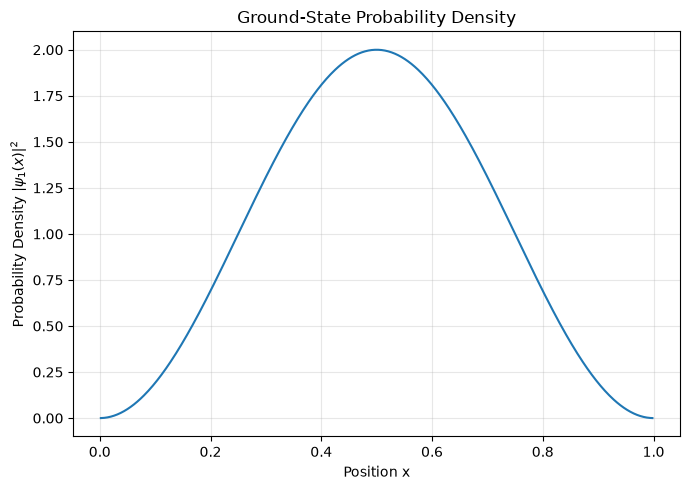

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(x_interior,np.abs(psi_1)**2)

plt.xlabel("Position x")
plt.ylabel(r"Probability Density $|\psi_1(x)|^2$")
plt.title("Ground-State Probability Density")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

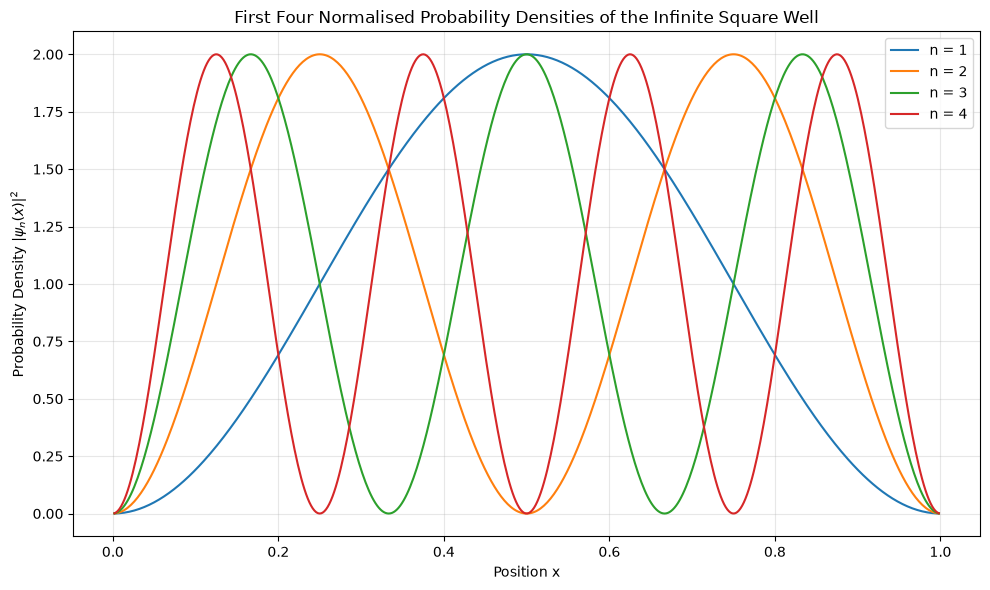

In [ ]:
plt.figure(figsize=(10, 6))

for n in range(4):

    psi_n_sq = np.abs(normalised_states[n])**2

    plt.plot(
        x_interior,
        psi_n_sq,
        label=f"n = {n + 1}"
    )

plt.xlabel("Position x")
plt.ylabel(r"Probability Density $|\psi_n(x)|^2$")
plt.title("First Four Normalised Probability Densities of the Infinite Square Well")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The numerically computed eigenfunctions replicate the expected spatial structure of the solutions for the infinite square well.

No internal nodes are present in the ground state, while the $n$th state contains $n-1$ internal nodes. Increasing $n$ therefore produces increasingly oscillatory wavefunctions.

Direct comparison with the analytical solutions

$$
\psi_n(x)
=
\sqrt{\frac{2}{L}}
\sin\left(\frac{n\pi x}{L}\right)
$$

shows very close agreement between the numerical and analytical eigenfunctions.

Together with the agreement of the numerical energy eigenvalues and the second-order convergence test, this provides both qualitative and quantitative validation of the discretised Hamiltonian.